## Clustering 📦📦📦

-----------------------------------------------

### What is Clustering?


Clustering, a pivotal technique in unsupervised learning, enables the identification of inherent groupings within data based on similarities among the data points. Unlike supervised learning, where models are trained on data labeled with the correct output, clustering algorithms seek to categorize data into clusters without prior knowledge of group assignments. These algorithms analyze the features of the data points and group them into clusters, where data points in the same cluster are more similar to each other than to those in other clusters. This method finds widespread applications across various domains, such as biology for genetic clustering, marketing for customer segmentation, and information technology for organizing similar documents or emails.

### K-means Clustering Algorithm
K-means is a popular clustering algorithm known for its simplicity and efficiency. The algorithm partitions the data into K distinct, non-overlapping subsets (clusters) by minimizing the variance within each cluster. The variance is measured as the sum of the squared distances between each data point and the centroid of its cluster. The centroids are the mean of the data points in a cluster, serving as the "center" of that cluster. 

#### Import the libraries

In [2]:
import numpy as np
import pandas as pd
#scikit is an open source data analysis library, and the gold standard for Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

#Suppress FutureWarnings, a indicator that certain features or behaviors in the code are planned to change in the future.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#### 1. Read the data

In [3]:
df = pd.read_csv('data/penguins_cluster.csv')
df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,39.1,18.7,181.0,3750.0
1,Adelie,39.5,17.4,186.0,3800.0
2,Adelie,40.3,18.0,195.0,3250.0
3,Adelie,36.7,19.3,193.0,3450.0
4,Adelie,39.3,20.6,190.0,3650.0
...,...,...,...,...,...
301,Gentoo,47.2,13.7,214.0,4925.0
302,Gentoo,46.8,14.3,215.0,4850.0
303,Gentoo,50.4,15.7,222.0,5750.0
304,Gentoo,45.2,14.8,212.0,5200.0


#### 2. Show the first 10 rows of the data

In [4]:
df.head(10)

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,39.1,18.7,181.0,3750.0
1,Adelie,39.5,17.4,186.0,3800.0
2,Adelie,40.3,18.0,195.0,3250.0
3,Adelie,36.7,19.3,193.0,3450.0
4,Adelie,39.3,20.6,190.0,3650.0
5,Adelie,38.9,17.8,181.0,3625.0
6,Adelie,39.2,19.6,195.0,4675.0
7,Adelie,41.1,17.6,182.0,3200.0
8,Adelie,38.6,21.2,191.0,3800.0
9,Adelie,34.6,21.1,198.0,4400.0


In [5]:
# Let's check the unique species we have in our data
df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [6]:
df[df['species']== 'Adelie'].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,124.000000,124.000000,124.000000,124.000000
mean,38.114516,18.170968,188.741935,3606.451613
std,2.145128,1.159112,5.787386,408.035037
min,32.100000,15.500000,172.000000,2850.000000
25%,36.475000,17.200000,185.000000,3325.000000
50%,38.150000,18.100000,189.500000,3550.000000
75%,39.700000,18.900000,193.000000,3881.250000
max,42.200000,21.200000,202.000000,4675.000000


#### 3. We are going work with the numerical data. Filter out the species column, name the dataset df_num and show the dataset.

In [8]:
df_num = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
df_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0


In [9]:
# We can also drop the column
#df.drop('species', inplace=True, axis =1)

#### 4. Use the `describe()` function to see if the variables in the data set have large differences between their ranges.

In [10]:
df_num.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,306.000000,306.000000,306.000000,306.000000
mean,44.104575,17.012745,201.444444,4217.810458
std,5.677102,1.942248,14.397354,827.289041
min,32.100000,13.100000,172.000000,2700.000000
25%,39.000000,15.300000,190.000000,3550.000000
50%,45.200000,17.200000,198.000000,3950.000000
75%,49.000000,18.600000,214.000000,4850.000000
max,59.600000,21.200000,231.000000,6300.000000


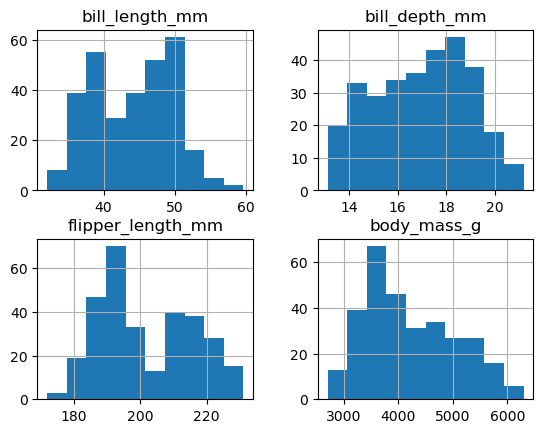

In [11]:
df_num.hist();

#### 5. Do you see any large difference? If yes which features? 

Body mass has way higher order of magnitude than dimension measures. Also flippers are longer than bills.

### REMINDER!! 
 
We use feature scaling when the variables in the data set have large differences in order of magnitude, or when they are similar in that sense but measured with different metrics such as meters vs kilometers, etc. 
These differences cause problems for many models. For example, if one of the features has a way higher order of magnitude, this particular feature will dominate over the other ones.



In [12]:
scaler = StandardScaler()
scaler.fit(df_num)
df_num_scaled = scaler.transform(df_num)
df_num_scaled

#Normalization: X_new = (X - X_min)/(X_max - X_min)
#Standardization: X_new = (X - mean)/Std


array([[-0.88298091,  0.87013517, -1.42234005, -0.56640027],
       [-0.81240701,  0.19971144, -1.07448514, -0.5058629 ],
       [-0.67125922,  0.50913778, -0.44834632, -1.17177393],
       ...,
       [ 1.11073163, -0.67699651,  1.43007016,  1.85509441],
       [ 0.19327099, -1.14113601,  0.73436035,  1.18918337],
       [ 1.02251426, -0.47071228,  0.80393133,  1.43133284]],
      shape=(306, 4))

#### 7. The standardized data is an array. Please convert the array to a pandas dataframe, Name the data df_penguins. (Hint: columns = df_num.columns) 

In [13]:
df_penguins = pd.DataFrame(df_num_scaled, columns=df_num.columns)
df_penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.882981,0.870135,-1.422340,-0.566400
1,-0.812407,0.199711,-1.074485,-0.505863
2,-0.671259,0.509138,-0.448346,-1.171774
3,-1.306424,1.179561,-0.587488,-0.929624
4,-0.847694,1.849985,-0.796201,-0.687475


#### 8. Check how does the scaled data look like.

In [14]:
df_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,3.060000e+02,3.060000e+02,3.060000e+02,3.060000e+02
mean,1.857628e-16,-1.300340e-15,-9.752547e-16,1.393221e-16
std,1.001638e+00,1.001638e+00,1.001638e+00,1.001638e+00
min,-2.118024e+00,-2.017844e+00,-2.048479e+00,-1.837685e+00
25%,-9.006244e-01,-8.832807e-01,-7.962012e-01,-8.085497e-01
50%,1.932710e-01,9.656933e-02,-2.396334e-01,-3.242508e-01
75%,8.637230e-01,8.185641e-01,8.735023e-01,7.654218e-01
max,2.733931e+00,2.159412e+00,2.056209e+00,2.521005e+00


#### Check the distribution again

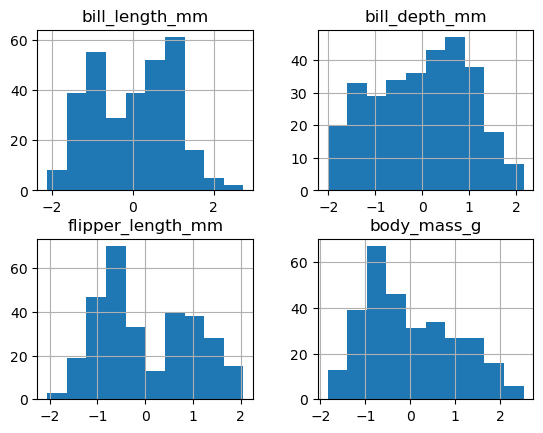

In [15]:
df_penguins.hist();

#### 9. Let's imagine that we don't know anything about the data and we assume there might be only two groups of penguins.

In [17]:
# Since we are not sure about how many clusters we should have, 
# we may need to generate the same labels again and again. Therefore using 'random state' is a good idea

kmeans = KMeans(n_clusters=2, #The number of clusters to form as well as the number of centroids to generate.
                random_state=42) #Determines random number generation for centroid initialization.
kmeans.fit(df_penguins)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


#### 10. Let's check which labels we have

In [18]:
# retrieve array of cluster labels from our kmeans model
clusters = kmeans.labels_
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [19]:
# retrieve unique clusters
labels = np.unique(clusters)
labels

array([0, 1], dtype=int32)

In [20]:
#How many penguins in which cluster?
#clusters = kmeans.predict(df_penguins)

pd.Series(clusters).value_counts().sort_index()

0    187
1    119
Name: count, dtype: int64

#### 11. Now we are adding the defined clusters to the dataframe

In [21]:
df_clustered = df_penguins.copy() 
df_clustered["cluster"] = clusters
df_clustered

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster
0,-0.882981,0.870135,-1.422340,-0.566400,0
1,-0.812407,0.199711,-1.074485,-0.505863,0
2,-0.671259,0.509138,-0.448346,-1.171774,0
3,-1.306424,1.179561,-0.587488,-0.929624,0
4,-0.847694,1.849985,-0.796201,-0.687475,0
...,...,...,...,...,...
301,0.546140,-1.708418,0.873502,0.856228,1
302,0.475567,-1.398991,0.943073,0.765422,1
303,1.110732,-0.676997,1.430070,1.855094,1
304,0.193271,-1.141136,0.734360,1.189183,1


In [20]:
df_clustered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     306 non-null    float64
 1   bill_depth_mm      306 non-null    float64
 2   flipper_length_mm  306 non-null    float64
 3   body_mass_g        306 non-null    float64
 4   cluster            306 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 10.9 KB


#### 12. Add real penguins species to the dataframe again 

In [22]:
df_clustered['species'] = df[['species']]
df_clustered

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster,species
0,-0.882981,0.870135,-1.422340,-0.566400,0,Adelie
1,-0.812407,0.199711,-1.074485,-0.505863,0,Adelie
2,-0.671259,0.509138,-0.448346,-1.171774,0,Adelie
3,-1.306424,1.179561,-0.587488,-0.929624,0,Adelie
4,-0.847694,1.849985,-0.796201,-0.687475,0,Adelie
...,...,...,...,...,...,...
301,0.546140,-1.708418,0.873502,0.856228,1,Gentoo
302,0.475567,-1.398991,0.943073,0.765422,1,Gentoo
303,1.110732,-0.676997,1.430070,1.855094,1,Gentoo
304,0.193271,-1.141136,0.734360,1.189183,1,Gentoo


#### 13. Let's check the mapping between the species and clusters

In [23]:
adelie = df_clustered.loc[df_clustered['species'] == 'Adelie']

In [24]:
adelie['cluster'].unique() # which label got Adelie?

array([0], dtype=int32)

In [25]:
gentoo = df_clustered.loc[df_clustered['species'] == 'Gentoo']
gentoo['cluster'].unique()

array([1], dtype=int32)

In [26]:
chinstrap = df_clustered.loc[df_clustered['species'] == 'Chinstrap']
chinstrap['cluster'].unique() # chinstrap and adelie got the same 

array([0], dtype=int32)

We see, Chinstrap and Adelie got the same cluster label ...

#### 14. Let's use elbow method to see how many clusters are recommended for this dataset (we know that there are 3 species in the dataset)

**The Elbow Method**

The elbow method is one of the most well-known methods in machine learning and could be also used for finding the optimal number of clusters. With calculating the **Within-Cluster-Sum of Squared Errors ([WSS](https://medium.com/analytics-vidhya/how-to-determine-the-optimal-k-for-k-means-708505d204eb))** for different values of k we can choose the k for which WSS first starts to decrease. In a plot this will show an elbow joint.


**Checking the inertia**

Clustering inertia measures the sum of squared distances between each point and its nearest cluster centroid, reflecting the compactness of clusters.

The following code calculates the inertia for K-means clustering and iterates over a different numbers of clusters.  
Then, it stores the inertia values in a list to help determine the optimal number of clusters for the dataset by plotting them in an elbow plot.

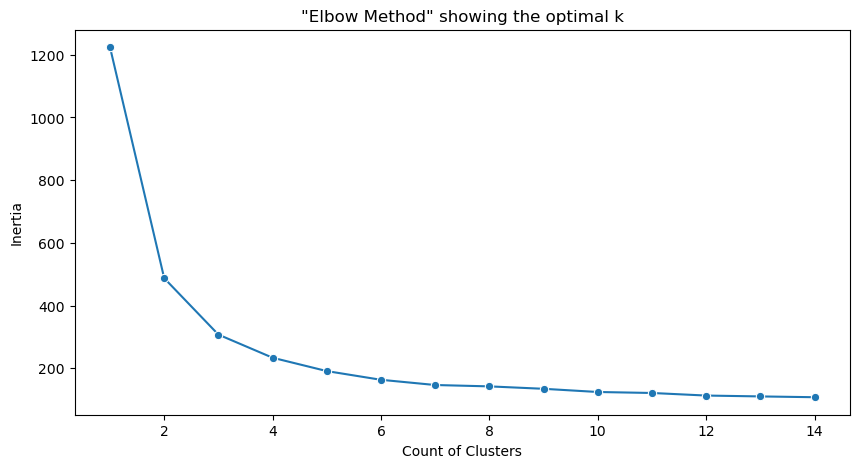

In [27]:

K = range(1, 15) #let's give it a range
inertia_list = []

for k in K:
    kmeans = KMeans(n_clusters=k,
                    random_state=1234) # a different random state
    kmeans.fit(df_penguins)
    inertia_list.append(kmeans.inertia_) 

# Generate the x-axis values (1, 2, 3, ...)
x = list(range(1, len(inertia_list) + 1))

# Create a Seaborn line plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=x, y=inertia_list, marker='o')

# Add labels and title
plt.xlabel('Count of Clusters')
plt.ylabel('Inertia')
plt.title('"Elbow Method" showing the optimal k')

# Remove the grid
plt.grid(False)

# Display the plot
plt.show()


We can see a light elbow for k = 3 which fits our knowledge of the dataset.

#### 15. Repeat k-means clustering with k = 3

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_penguins)

clusters = kmeans.labels_
df_clustered_3 = df_penguins.copy() 
df_clustered_3["cluster"] = clusters
df_clustered_3

#labels = np.unique(labels)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster
0,-0.882981,0.870135,-1.422340,-0.566400,2
1,-0.812407,0.199711,-1.074485,-0.505863,2
2,-0.671259,0.509138,-0.448346,-1.171774,2
3,-1.306424,1.179561,-0.587488,-0.929624,2
4,-0.847694,1.849985,-0.796201,-0.687475,2
...,...,...,...,...,...
301,0.546140,-1.708418,0.873502,0.856228,1
302,0.475567,-1.398991,0.943073,0.765422,1
303,1.110732,-0.676997,1.430070,1.855094,1
304,0.193271,-1.141136,0.734360,1.189183,1


<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

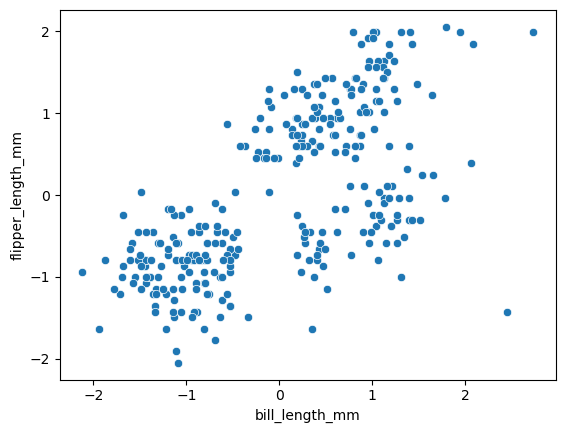

In [30]:
sns.scatterplot(data= df_clustered_3,x="bill_length_mm", y= "flipper_length_mm")

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

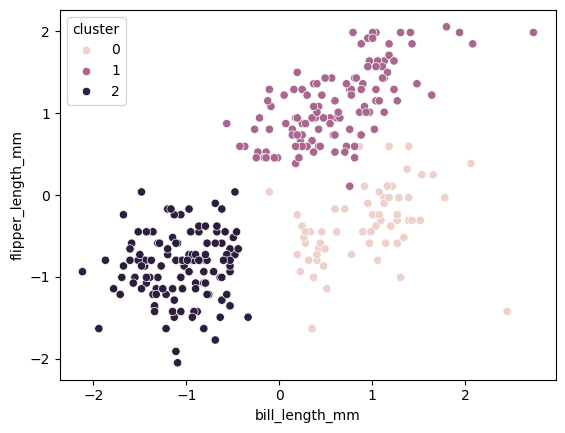

In [31]:
sns.scatterplot(data= df_clustered_3,x="bill_length_mm", y= "flipper_length_mm", hue="cluster")


<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

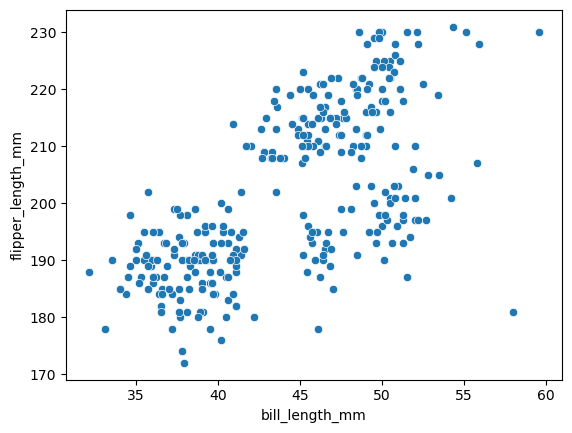

In [32]:
sns.scatterplot(data= df,x="bill_length_mm", y= "flipper_length_mm")


In [33]:
df_clustered_3['species'] = df[['species']]
df_clustered_3

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster,species
0,-0.882981,0.870135,-1.422340,-0.566400,2,Adelie
1,-0.812407,0.199711,-1.074485,-0.505863,2,Adelie
2,-0.671259,0.509138,-0.448346,-1.171774,2,Adelie
3,-1.306424,1.179561,-0.587488,-0.929624,2,Adelie
4,-0.847694,1.849985,-0.796201,-0.687475,2,Adelie
...,...,...,...,...,...,...
301,0.546140,-1.708418,0.873502,0.856228,1,Gentoo
302,0.475567,-1.398991,0.943073,0.765422,1,Gentoo
303,1.110732,-0.676997,1.430070,1.855094,1,Gentoo
304,0.193271,-1.141136,0.734360,1.189183,1,Gentoo


In [34]:
adelie_3 = df_clustered_3.loc[df_clustered_3['species'] == 'Adelie']
adelie_3['cluster'].unique() # which label got Adelie?

array([2], dtype=int32)

In [35]:
gentoo_3 = df_clustered_3.loc[df_clustered_3['species'] == 'Gentoo']
gentoo_3['cluster'].unique()

array([1], dtype=int32)

In [36]:
chinstrap_3 = df_clustered_3.loc[df_clustered_3['species'] == 'Chinstrap']
chinstrap_3['cluster'].unique() 

array([0], dtype=int32)

### Let's build our penguin species finder

#### Notes to the teacher:
This part is optional. The idea is to show where we can use clustering in a simple penguin game. Depending on the level, this part can be used, otherwise please skip

#### 16. The function below is prepared to give you the correct penguin species according to the body mass input you give. Until this point if you followed the instructions correctly and named the dataframes as requested, your species finder should be working without any problem. The function basically gets the input from the user, converts it to a dataframe, standardize the data fitting the same scale you used above, predicting the cluster and giving the name of the species from the same cluster. Enjoy!

In [68]:
# def penguin_find():
#     bill = int(input("tell me your penguin's bill_length in mm (between 32-60 mm ): " ))
#     bill_d = int(input("tell me your penguin's bill_depth in mm (between 13-21 mm): " ))
#     flipper = int(input("tell me your penguin's flipper length in mm (between 172-230 mm ): "))
#     mass = int(input("tell me your penguin's body mass in gram (between 2700-6300 g): "))
#     penguins = {'bill_length_mm': bill, 'bill_depth_mm': bill_d, 'flipper_length_mm': flipper, 'body_mass_g': mass}
#     penguins_df = pd.DataFrame(penguins, index=['0'])
#     p_scaled = scaler.transform(penguins_df)
#     p_scaled_df = pd.DataFrame(p_scaled, columns = penguins_df.columns)
#     cluster1 = kmeans.predict(p_scaled_df)
#     cluster2 = cluster1[0]
#     if cluster2 == 0 :
#         print ("your penguin is a gentoo!")
#         im_gentoo = Image.open(r"./pinguin_pic/gentoo.jpg") #creates an object
#         display(im_gentoo)
#     elif cluster2 == 1 :
#         print ("your penguin is a adelie!")
#         im_adelie = Image.open(r"./pinguin_pic/adelie.jpg") #creates an object
#         display(im_adelie)
#     else :
#         print ("your penguin is a chinstrap!")
#         im_chinstrap = Image.open(r"./pinguin_pic/chinstrap.jpg") #creates an object
#         display(im_chinstrap)
# penguin_find()